<a href="https://colab.research.google.com/github/YayraBoven/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Harriet Yayra Boven Fiahagbe
**Student ID:** 59722028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

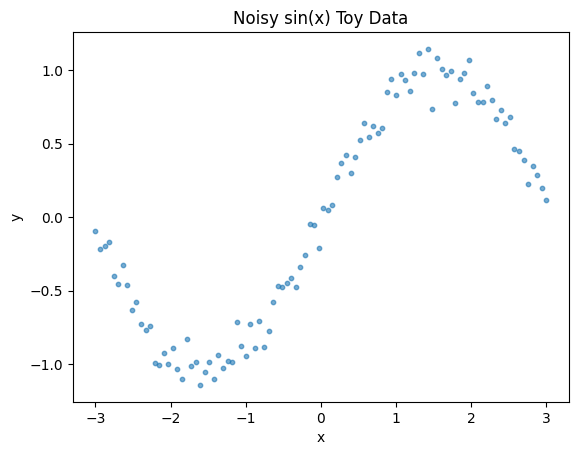

Final loss computed:  0.19545212040311394
Final w, b:  0.3390312757270389 -0.010941835786772039


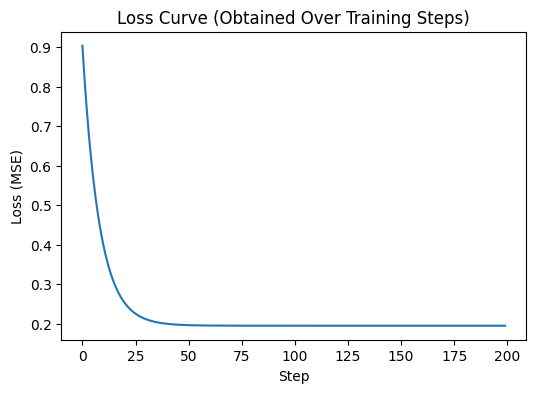

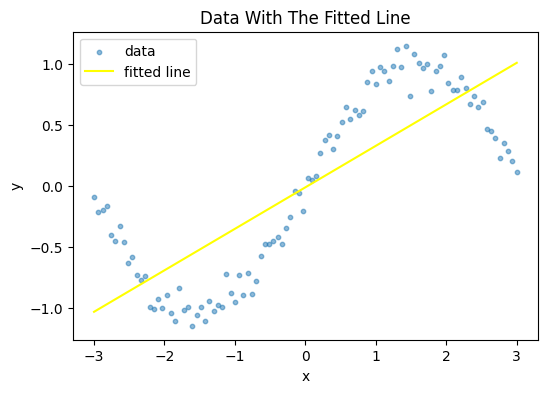

In [3]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
x = np.linspace(-3, 3, 100)
noise =  np.random.normal(0,0.1, size=x.shape)
y = np.sin(x) + noise

#   Plot it.
plt.scatter(x, y, s=10, alpha=0.6)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy sin(x) Toy Data")
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr = 0.01
losses =[]
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

for step in range(200):
  #computing our forward pass
  y_hat = w * x + b

  #computing our loss
  loss  = np.mean((y_hat - y) ** 2)
  losses.append(loss)

  #computing our gradients
  dw    = np.mean(2 * (y_hat - y) * x)
  db    = np.mean(2 * (y_hat - y))

  #updating data we have gotten from computation
  w    -= lr * dw
  b    -= lr * db

print(f"Final loss computed: " , losses[-1])
print("Final w, b: ", w,b)

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

# A) The loss curve over the 200 steps
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss (MSE)")
plt.title("Loss Curve (Obtained Over Training Steps)")
plt.show()

#B) The Data with the fitted line on top
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=10, alpha=0.5, label="data")
plt.plot(x, y_hat, color='yellow', label="fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Data With The Fitted Line")
plt.legend()
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:**
I think this is underfitting, because the model is too simple, especially since it is  linear model. The model is not able to learn the correct main patterns in the data  because it is linear, yet the data is originally a sine-curve shaped. This is caused by a high bias, as a straight line is being used to make prediction for a curved data.
Also it could be that the the looping time of 200 steps may be small and the model may need more training time, yet we can see that it is already in a plateau, so the added training time is likely to still result in the same underfitting .
A single neuron on the other hand, can never fit a sine wave, no matter how long you train because a single neuron originally is a linear structure. Therefore it is not able to fit a sine wave, which is curved or non- linear. This means that no matter how much you train it regardless of how many training steps are used or how the weights are adjusted, a single neuron with no non linearity is never going to fit a sine wave.



### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

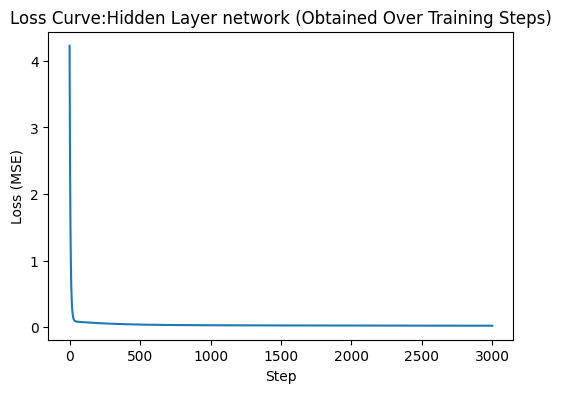

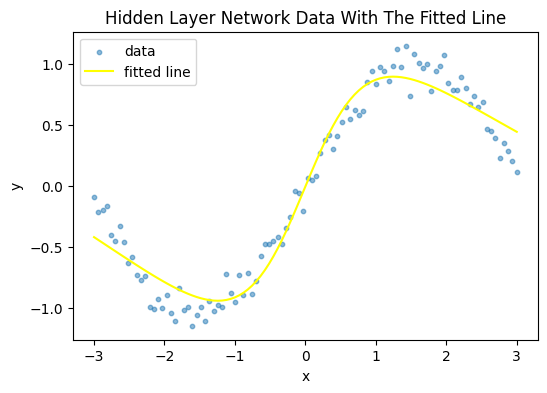

In [4]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
W1= np.random.randn(1,8) * 0.5
b1= np.random.randn(8,) * 0.5
W2= np.random.randn(8,1) * 0.5
b2= np.random.randn(1) * 0.5

x = x.reshape(-1,1)
y = y.reshape(-1,1)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

z1 = x @ W1 + b1
h  = np.tanh(z1)
y_hat = h @ W2 + b2
loss  = np.mean((y_hat - y) ** 2)


# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat
db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)
dW1 = x.T @ dz1
db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

lr = 0.01
losses =[]


for step in range(3000):
  #computing our forward pass
  z1 = x @ W1 + b1
  h  = np.tanh(z1)
  y_hat = h @ W2 + b2
  loss  = np.mean((y_hat - y) ** 2)
  losses.append(loss)

  #computing our backward pass
  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x.T @ dz1
  db1 = dz1.sum(axis=0)

  #updating all our parameter
  W1   -= lr * dW1
  b1   -= lr * db1
  W2   -= lr * dW2
  b2   -= lr * db2

# TODO: Plot the loss curve AND the final fit over the data.
#The loss curve
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss (MSE)")
plt.title("Loss Curve:Hidden Layer network (Obtained Over Training Steps)")
plt.show()

#B)Final fit over the date
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=10, alpha=0.5, label="data")
plt.plot(x, y_hat, color='yellow', label="fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Hidden Layer Network Data With The Fitted Line")
plt.legend()
plt.show()


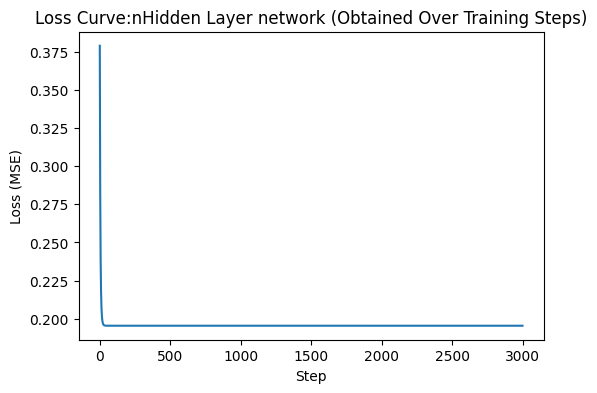

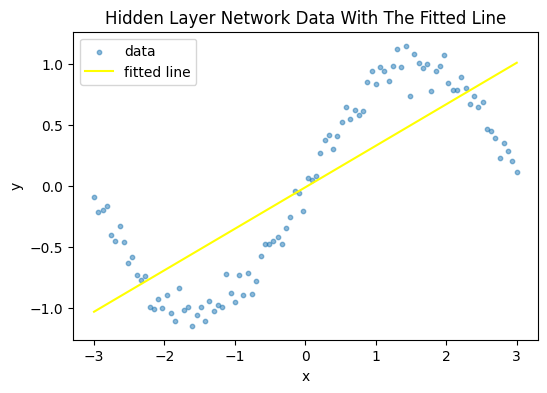

In [5]:
#REMOVING TANH
#Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

W1= np.random.randn(1,8) * 0.5
b1= np.random.randn(8,) * 0.5
W2= np.random.randn(8,1) * 0.5
b2= np.random.randn(1) * 0.5


lr = 0.01
losses =[]


for step in range(3000):
  #computing our forward pass (No tanh)
  z1 = x @ W1 + b1
  h  = z1
  y_hat = h @ W2 + b2
  loss  = np.mean((y_hat - y) ** 2)
  losses.append(loss)

  #computing our backward pass
  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  dz1 = dh
  dW1 = x.T @ dz1
  db1 = dz1.sum(axis=0)

  #updating all our parameter
  W1   -= lr * dW1
  b1   -= lr * db1
  W2   -= lr * dW2
  b2   -= lr * db2


#NEW GRAPHS PLOTTED
# TODO: Plot the loss curve AND the final fit over the data.
#The loss curve
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss (MSE)")
plt.title("Loss Curve:nHidden Layer network (Obtained Over Training Steps)")
plt.show()

#B)Final fit over the date
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=10, alpha=0.5, label="data")
plt.plot(x, y_hat, color='yellow', label="fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Hidden Layer Network Data With The Fitted Line")
plt.legend()
plt.show()


**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:**
1. Mathematically with h= z1 the forward pass becomes y_hat = (xW1+b1)W2+b2 which is equal to x(W1W2) + (b1W2+b2) when expanded. Now since W1W2 and b1W2+b2 are fixed or constant numbers as we multiply them,  we can say its almost similar to the formal of a straight line as the single neuron in part 1.1 being y_hat = w'x + b'. This shows that, as explained in the previous part, stacking up linear layers with no activation, does not make any changes to the linearity of the curve. At the end of the  day, all  neurons collapses into one linear function, despite the numbers of layers stacked together.
2. The role of each of the 8 neurons in the hidden layer, helped to compute its own bent curve, where each of the curves were positioned differently based on its respective weight and bias added. The main output layer then combined  the different 8 curved pieces into one final combined curve, which is seen in the second graph plotted in Part 2. The tanh version with h= np.tanh(z1), showed that the tanh had an influence with the 8 neurons as input, helping them have curved building blocks combined in order to follow the sine wave.
3. Backpropagation  is the process of using the chain rule to compute how much each weight in the model contributed to the loss, working layer by layer backwards from that loss, so each weight can be updated to reduce the loss or error.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_650/1924853331.py:17: RuntimeWarning: overflow encountered in square
  loss  = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_650/1924853331.py:24: RuntimeWarning: overflow encountered in matmul
  dh  = d_yhat @ W2.T
/tmp/ipykernel_650/1924853331.py:25: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


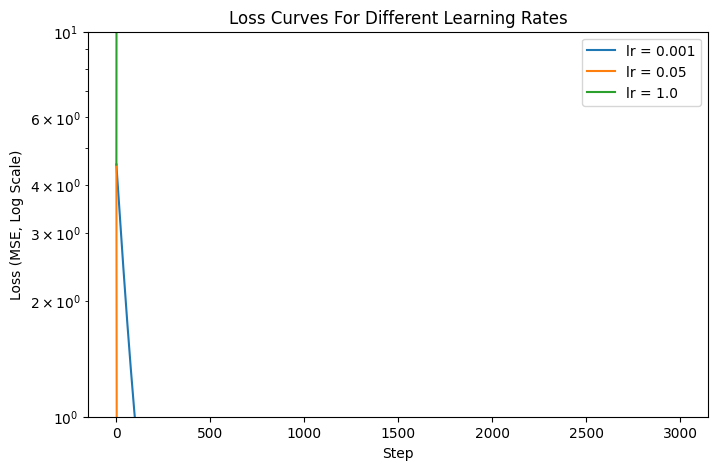

0.97026084928532
0.07181850562493927


In [6]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps = 3000):
  np.random.seed(RANDOM_STATE)
  W1= np.random.randn(1,8) * 0.5
  b1= np.random.randn(8,) * 0.5
  W2= np.random.randn(8,1) * 0.5
  b2= np.random.randn(1) * 0.5

  losses =[]

  #computing our forward pass (No tanh)
  for steps in range(steps):
    z1 = x @ W1 + b1
    h  = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss  = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    #computing our backward pass
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    #updating all our parameter
    W1   -= lr * dW1
    b1   -= lr * db1
    W2   -= lr * dW2
    b2   -= lr * db2
  return losses

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
small_losses = train_toy(lr= 0.001)
mid_losses = train_toy(lr= 0.05)
big_losses = train_toy(lr= 1.0)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.

plt.figure(figsize=(8,5))
plt.plot(small_losses, label="lr = 0.001")
plt.plot(mid_losses, label="lr = 0.05")
plt.plot(big_losses, label="lr = 1.0")
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss (MSE, Log Scale)")
plt.title("Loss Curves For Different Learning Rates")
plt.legend()
plt.show()

print(small_losses[100])
print(small_losses[-1])

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:**


Each of the three curve show different learning rate effect in regards to increase and decrease of the loss computed. When the learning rate is 0.001, the loss decreases very slowly, as it reaches around 1.0 within the first 100 plus steps it takes. This shows that training seems to be stable yet very slow to reach a good fit within a reasonable number of steps. On the other hand, with the learning rate of 0.05, the loss drops sharply and quickly converges to a low value, which is similar to the well-fitted result from Part 1.2. Lastly with the learning rate 1.0, the loss does not converge at all, it explores almost immediately, triggering extremely large numbers to the extent of producing NaN values.

A too-large learning rate makes the loss explode or oscillate instead of just "learning faster" because  each weight update overshoot the minimum by such a large margin that the new position becomes worse than before. This is because since the next gradient is computed from this worse position, the next update is likely to be even larger and way off target, creating a inaccurate feedback loop where each step makes things worse instead of better. In using a large learning rate there is a little possibility of getting  a closely accurate  convergent descent toward the minimum loss.


---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [7]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
obesity = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv')

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

#Binary yes/no -> 0/1
obesity['family_history_with_overweight'].unique()
obesity['FAVC'].unique()
obesity['SMOKE'].unique()
obesity['SCC'].unique()

binary_mapping = {"yes": 1, "no":0}

obesity['family_history_with_overweight'] = obesity['family_history_with_overweight'].map(binary_mapping)
obesity['FAVC'] = obesity['FAVC'].map(binary_mapping)
obesity['SMOKE'] = obesity['SMOKE'].map(binary_mapping)
obesity['SCC'] = obesity['SCC'].map(binary_mapping)

#Encoding Ordinal values
ordinal_mapping = {"no":0, "Sometimes":1, "Frequently":2, "Always":3 }
obesity['CAEC'] = obesity['CAEC'].map(ordinal_mapping)
obesity['CALC'] = obesity['CALC'].map(ordinal_mapping)

#Encoding Nominal vales
obesity['Gender'].unique()
obesity['MTRANS'].unique()

obesity = pd.get_dummies(obesity, columns=['MTRANS', 'Gender'], drop_first=True)

#BMI Feature
obesity['BMI'] = obesity['Weight']/(obesity['Height'] **2)

#Encode the target NObeyesdad into integers
from sklearn.preprocessing import LabelEncoder
main_encoder = LabelEncoder()
obesity["NObeyesdad"] = main_encoder.fit_transform(
    obesity["NObeyesdad"]
)

#Creating out X and y
y = obesity["NObeyesdad"]
X= obesity.drop("NObeyesdad",axis =1)


# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).

from sklearn.model_selection import train_test_split

#First split off the test set (20% of the whole dataset)
X_temp, X_test, y_temp, y_test = train_test_split(
   X, y,
   test_size = 0.2,
   stratify=y,
   random_state = RANDOM_STATE)

#Second split: split the rest fo the 80% temp into 60% train and 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size = 0.25,
    stratify=y_temp,
    random_state = RANDOM_STATE)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)

from sklearn.preprocessing import StandardScaler
#Fitting on train obly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

#Converting features to tensors
X_train_tensor= torch.tensor(X_train_scaled, dtype = torch.float32)
X_val_tensor= torch.tensor(X_val_scaled, dtype = torch.float32)
X_test_tensor= torch.tensor(X_test_scaled, dtype = torch.float32)

#Converting labels to tensors
y_train_tensor= torch.tensor(y_train.values, dtype = torch.long)
y_val_tensor= torch.tensor(y_val.values, dtype = torch.long)
y_test_tensor= torch.tensor(y_test.values, dtype = torch.long)

#Splitting dataset and waraping in DataLoaders
train_dataset = TensorDataset(X_train_tensor , y_train_tensor)
val_dataset = TensorDataset(X_val_tensor , y_val_tensor)
test_dataset = TensorDataset(X_test_tensor , y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle=False)

**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:**
1. CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch because CrossEntropyLoss is structured to be very efficient as it combines two operation internally, being the log-softmax(which converts the model's raw output into probabilities) and negative log-likelihood loss(which compares the probabilities to the true class or category).  In order for this to be done correctly, it needs to know which single index is correct instead of a full vector. Therefore, it normally demands the integer class index and ends up computing everything internally without one constructing one-hot vectors manually.

2. This is because the gradient becomes bigger for features who normally have larger raw values because the gradient formula seen in part 1 multiplies directly by x (eg: dw    = np.mean(2 * (y_hat - y) * x) ). This shows that a feature like Weight having a range of 40 to 180, produces much larger gradients than a feature like FCVC which ranges from 1 to 3. Now, even if both features are vital features for predicting the obesity level, the model would tens to give more influence to the weights during training, all because of its units and not because they are more predictive. Having to scale all features to a similar range with a mean and standard deviation fixes this making sure all features contributed to a fair gradient. A random forest on the other hand doesn't have a problem because it splits data using different threshold rather than the gradient.

3. The shuffle=True on the training DataLoader helps randomly reshuffles the order of the training data at the start of every epoch, so each epoch sees a different random nix of batches. This helps the model to generalize better and prevent the model from leaning the patterns tire to the data ordering. This also means the gradients update would be based on a varied sample of data each time.  This helps because without shuffling the DataLoader would feed the model batches in the exact same order every single epoch. This can lead to a bias training where the model might start overfitting to the patterns based on the order of data rather that the feature to label relationship. It may actually start memorizing the patterns.



### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [8]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

class FeedForwardNet(nn.Module):
  def __init__(self,input_dim,hidden_sizes=(64, 32), n_classes=7 ):
    super().__init__()
    self.relu= nn.ReLU()
    self.fc1 = nn.Linear(input_dim,hidden_sizes[0])
    self.fc2 = nn.Linear(hidden_sizes[0],hidden_sizes[1])
    self.classifier = nn.Linear (hidden_sizes[1],n_classes)

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.relu(x)
    out = self.classifier(x)
    return out

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X_train_scaled.shape[1]
model = FeedForwardNet(input_dim = input_dim,hidden_sizes=(64, 32), n_classes=7)
model = model.to(DEVICE)

print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

total_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total Trainable Parameters: " , total_parameters)

FeedForwardNet(
  (relu): ReLU()
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (classifier): Linear(in_features=32, out_features=7, bias=True)
)
Total Trainable Parameters:  3655


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:**

1.

2. ReLU would be here instead of tanh in this section because  ReLU is much less prone to vanishing gradients  compared to tanh, since its derivative stays a constant 1 for all positive input instead of extremely shrinking toward 0  for large-magnitude input. ReLU is also cheaper to compute than tanh. While tanh deals with exponentials, ReLU deals with only requires a comparison of  f(x) = max(0, x).

3. If ReLUs were removed from the network, it would compute a linear output. Without any non-linear activation, no matter how many linear layers are stacked, the network collapses into a single linear function, which has been proved mathematically in part 1.2 above.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 1/100 — train_loss: 0.0001, train_acc: 1.0000, val_loss: 0.4926, val_acc: 0.9526
Epoch 2/100 — train_loss: 0.0001, train_acc: 1.0000, val_loss: 0.5120, val_acc: 0.9502
Epoch 3/100 — train_loss: 0.0001, train_acc: 1.0000, val_loss: 0.4936, val_acc: 0.9431
Epoch 4/100 — train_loss: 0.0000, train_acc: 1.0000, val_loss: 0.5069, val_acc: 0.9455
Epoch 5/100 — train_loss: 0.0000, train_acc: 1.0000, val_loss: 0.4981, val_acc: 0.9479
Epoch 6/100 — train_loss: 0.0000, train_acc: 1.0000, val_loss: 0.5035, val_acc: 0.9479
Epoch 7/100 — train_loss: 0.0000, train_acc: 1.0000, val_loss: 0.5029, val_acc: 0.9479
Epoch 8/100 — train_loss: 0.0000, train_acc: 1.0000, val_loss: 0.5031, val_acc: 0.9479
Epoch 9/100 — train_loss: 0.0000, train_acc: 1.0000, val_loss: 0.5057, val_acc: 0.9479
Epoch 10/100 — train_loss: 0.0000, train_acc: 1.0000, val_loss: 0.5078, val_acc: 0.9479
Epoch 11/100 — train_loss: 0.0000, train_acc: 1.0000, val_loss: 0.5109, val_acc: 0.9479
Epoch 12/100 — train_loss: 0.0000, train_

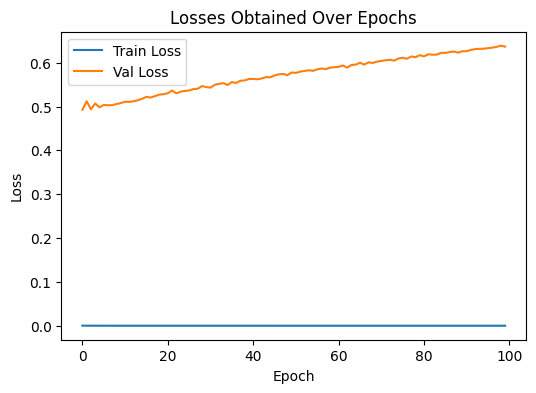

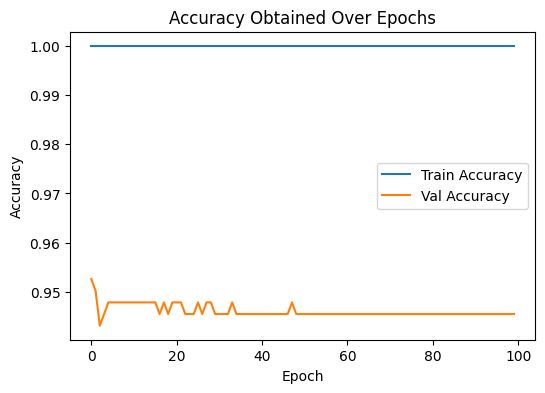

In [46]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [] , "val_acc": []
}

num_epochs = 100
best_val_acc = 0.0

for epoch in range(num_epochs):
  #Training:(Looping over batches)
  model.train();
  for xb, yb in train_loader:
    optimizer.zero_grad()
    logits = model(xb.to(DEVICE))
    loss = criterion(logits, yb.to(DEVICE))
    loss.backward()
    optimizer.step()


  #Evaluating
  model.eval()
  with torch.no_grad():
    train_logits= model(X_train_tensor.to(DEVICE))
    train_loss= criterion(train_logits, y_train_tensor.to(DEVICE)).item()
    train_preds = train_logits.argmax(dim=1)
    train_acc = (train_preds.cpu() == y_train_tensor).float().mean().item()

    val_logits= model(X_val_tensor.to(DEVICE))
    val_loss= criterion(val_logits, y_val_tensor.to(DEVICE)).item()
    val_preds = val_logits.argmax(dim=1)
    val_acc = (val_preds.cpu() == y_val_tensor).float().mean().item()


  #Recording history
  history["train_loss"].append(train_loss)
  history["train_acc"].append(train_acc)
  history["val_loss"].append(val_loss)
  history["val_acc"].append(val_acc)

  #Printing one line summary for each epoch
  print(f"Epoch {epoch+1}/{num_epochs} — train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")


# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
if val_acc > best_val_acc:
  best_val_acc = val_acc
  torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.

plt.figure(figsize=(6,4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Obtained Over Epochs")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Obtained Over Epochs")
plt.legend()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:**
1. Mapping the forward pass, the computation of the loss,gradients and the update rule respectively.

logits = model(xb.to(DEVICE)) IS EQUIVALENT TO computing [z1 = x @ W1 + b1 , h  = np.tanh(z1) , y_hat = h @ W2 + b2 ]

loss = criterion(logits, yb.to(DEVICE)) IS EQUIVALENT TO computing [loss  = np.mean((y_hat - y) ** 2)]

loss.backward()  IS EQUIVALENT TO computing [d_yhat, dW2, db2, dh, dz1, dW1,db1]

optimizer.step()  IS EQUIVALENT TO computing [W1 -= lr * dW1 , b1   -= lr * db1]

2. The graphs show that the model is overfitting. During training, the loss  did not oscillate or move at all, it was completely stagnant.  During validation, the loss were oscillating, showing that the  validation performance was getting worse over time. Moving on the to the values recorded, the train loss is 0.0000 and train accuracy is 1.0000 from epoch 1 up to epoch 100 meaning the model had memorized the training data. Meanwhile, the validation loss  slowly increased from 0.74 at epoch 1 to 0.83 at epoch 100, while validation accuracy remained around 0.945 to 0.95 without meaningful improvement after roughly epoch 30.  Overall,  the fact that the train loss is perfect while validation loss keeps getting worse over time is a clear signature of overfitting.  The model is memorizing training examples and becoming overconfident and wrong on unseen data.

3. We call the optimizer.zero_grad() for every batch because PyTorch is designed to add all new gradient into .grad by default rather than overwriting them on each backward() call. If this reset is not done for each batch, gradients from previous batches would keep accumulating on top of the current batch's gradients, growing larger and larger without reflecting only the current batch's data, corrupting the weight updates and leading to an unstable or incorrect training.


### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [10]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

In [11]:
#Adding dropout support to our feedforward network
class FeedForwardNet(nn.Module):
  def __init__(self,input_dim,hidden_sizes=(64, 32), n_classes=7, dropout = 0.0 ):
    super().__init__()
    self.relu= nn.ReLU()
    self.dropout = nn.Dropout(dropout)
    self.fc1 = nn.Linear(input_dim,hidden_sizes[0])
    self.fc2 = nn.Linear(hidden_sizes[0],hidden_sizes[1])
    self.classifier = nn.Linear (hidden_sizes[1],n_classes)

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc2(x)
    x = self.relu(x)
    x = self.dropout(x)
    out = self.classifier(x)
    return out

In [30]:
#Wrapping our Part2.3 loop into a function
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=100, dropout=0.0):

  #Rebuilding DataLoaders with the given batch size
  train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
  val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle=False)

  #Rebuilding the model with the new given hyperparameters
  model = FeedForwardNet(input_dim = input_dim,hidden_sizes=hidden_sizes, n_classes=7, dropout=dropout)
  model = model.to(DEVICE)

  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)


  history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [] , "val_acc": []
}

  for epoch in range(epochs):

    #Training:(Looping over batches)
    model.train();
    for xb, yb in train_loader:
      optimizer.zero_grad()
      logits = model(xb.to(DEVICE))
      loss = criterion(logits, yb.to(DEVICE))
      loss.backward()
      optimizer.step()

    #Evaluating
    model.eval()
    with torch.no_grad():
      train_logits= model(X_train_tensor.to(DEVICE))
      train_loss= criterion(train_logits, y_train_tensor.to(DEVICE)).item()
      train_preds = train_logits.argmax(dim=1)
      train_acc = (train_preds.cpu() == y_train_tensor).float().mean().item()

      val_logits= model(X_val_tensor.to(DEVICE))
      val_loss= criterion(val_logits, y_val_tensor.to(DEVICE)).item()
      val_preds = val_logits.argmax(dim=1)
      val_acc = (val_preds.cpu() == y_val_tensor).float().mean().item()


    #Recording history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

  return history


In [31]:
#Rebuild our feedforward network to be able to accomodate different hidden sizes

class FeedForwardNet(nn.Module):
  def __init__(self,input_dim,hidden_sizes=(64, 32), n_classes=7, dropout = 0.0 ):
    super().__init__()

    layers = []
    prev_size = input_dim

    for h in hidden_sizes:
      layers.append(nn.Linear(prev_size,h))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout))
      prev_size = h

    layers.append(nn.Linear(prev_size,n_classes))

    self.network = nn.Sequential(*layers)

  def forward(self, x):
    return self.network(x)


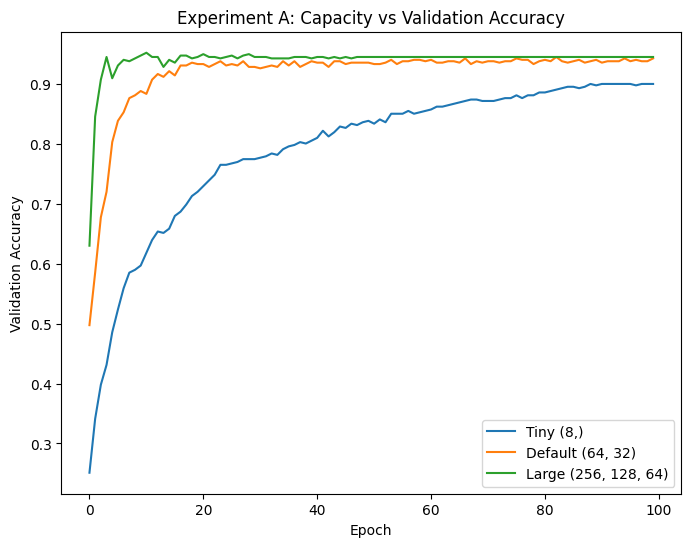

In [27]:
# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
history_tiny = run_experiment(hidden_sizes=(8,), epochs=100)
history_default = run_experiment(hidden_sizes=(64,32), epochs=100)
history_large = run_experiment(hidden_sizes=(256,128,64), epochs=100)


#Plotting the three validation curves
plt.figure(figsize=(8,6))
plt.plot(history_tiny['val_acc'], label='Tiny (8,)')
plt.plot(history_default['val_acc'], label='Default (64, 32)')
plt.plot(history_large['val_acc'], label='Large (256, 128, 64)')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A: Capacity vs Validation Accuracy")
plt.legend()
plt.show()


#

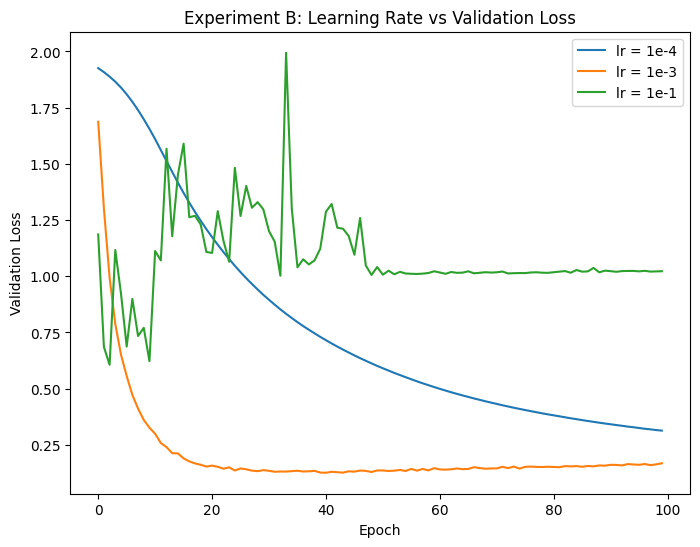

In [21]:
# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

history_lr_tiny = run_experiment(hidden_sizes=(64,32), lr = 1e-4, epochs=100)
history_lr_middle = run_experiment(hidden_sizes=(64,32),lr = 1e-3, epochs=100)
history_lr_large = run_experiment(hidden_sizes=(64,32), lr = 1e-1, epochs=100)

plt.figure(figsize=(8,6))
plt.plot(history_lr_tiny['val_loss'], label='lr = 1e-4')
plt.plot(history_lr_middle['val_loss'], label='lr = 1e-3')
plt.plot(history_lr_large['val_loss'], label='lr = 1e-1')
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Experiment B: Learning Rate vs Validation Loss")
plt.legend()
plt.show()


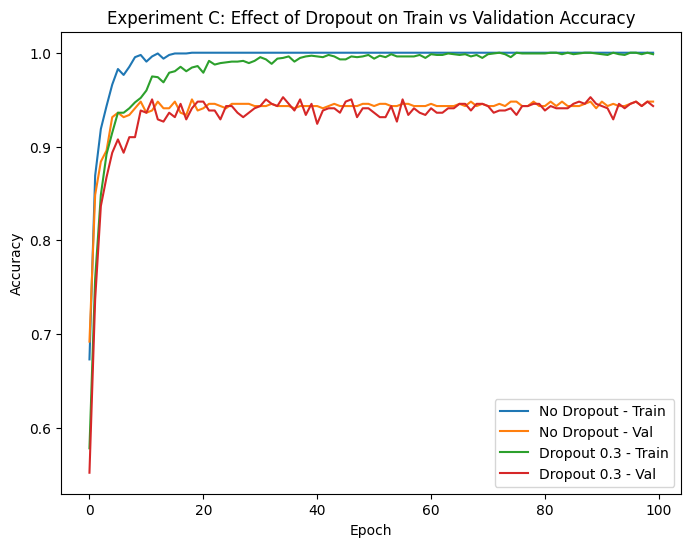

In [23]:
# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

history_large_no_dropout = run_experiment(hidden_sizes=(256,128,64),dropout= 0.0, epochs=100)
history_large_with_dropout = run_experiment(hidden_sizes=(256,128,64),dropout= 0.3, epochs=100)

plt.figure(figsize=(8,6))
plt.plot(history_large_no_dropout['train_acc'], label='No Dropout - Train')
plt.plot(history_large_no_dropout['val_acc'], label='No Dropout - Val')
plt.plot(history_large_with_dropout['train_acc'], label='Dropout 0.3 - Train')
plt.plot(history_large_with_dropout['val_acc'], label='Dropout 0.3 - Val')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment C: Effect of Dropout on Train vs Validation Accuracy")
plt.legend()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:**
1. Based on the graphs obtained from our computation, no the largest network did not win  the default network on validation accuracy. Both plateaued and stayed constant at almost the same value around 0.93-90.95 by roughly epoch 20-30. The tiny network on the other hand clearly underperformed both, as it is still climbing slowly and only reach around 0.88 to 0.90 by epoch 100. This shows the diminishing returns from added capacity, that is going from tiny to default gave a large improvement in validation accuracy, yet going from default to large have almost no further improvement or difference despite having far more parameters.  Also since this experiment only tracked validation accuracy for each model, we cannot not conclude from this digram alone wether large is overfitting more than default unless a training accuracy is tracked on the models.

2. Yes the three regimes match what was observed on the toy problem in part 1.3, though there are some differences with the "too large" regime. Starting with lr = 1e-4, we can conclude it is the "too slow" regime as the loss decreased smoothly and steadily yet it still descending even after the 100 epochs. From the graph, it never full converged within the given training time just like lr=0.001 in part 1.3. Moving to lr = 1e-3 show the "just right" regime, which is the loss drops quickly and smoothly, settling at the lowest validation loss (0.15) by around epoch 20, matching the "just right" regime with lr=0.05 in part 1.3.  Lastly, lr = 1e-1 shows the "too large" regime as the loss oscillates for roughly th first 50 epochs, going high as to 2.0 before eventually settling at the poor plateau around 1.0, which is still greater than the other two learning rate in regards to the validation loss. This connect to the instability seen with lr=1.0 in part 1.3, yet as compared to lr being 1e-1, it does not diverge to infinity or NaN, showing that its a milder version of the overshooting behavior.

3. From this experiment, dropout did not really have any effect on the train vs validation gap. Both the no dropout and dropout=0.3 reached roughly 100% train accuracy and plateaued at roughly the same validation accuracy that is 0.94-0.95, showing that the gap between the train validation performance remained almost the same with no extreme changes, both with or without dropout used. One thing to note is this differs from what dropout  is theoretically expected to do.  This shows that the dataset used here may be small and fairly easy to classify, meaning the network may not have needed as much regularization to generalize well in the first place.

Dropout achieves this by randomly disabling a fraction of neurons on every training pass, which prevent the network from relying too heavily on any small subset of neurons to memorize some training examples. This forces the network to learn useful patterns , which in the long run reduced overfitting.

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [36]:
#Training and saving our feedforward network one last time so it can be used in part 2.5
model = FeedForwardNet(input_dim = input_dim,hidden_sizes=(64,32), n_classes=7, dropout=0.0)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loader = DataLoader(train_dataset, batch_size =32, shuffle=True)

num_epochs = 100
best_val_acc = 0.0

for epoch in range(num_epochs):
  #Training:(Looping over batches)
  model.train();
  for xb, yb in train_loader:
    optimizer.zero_grad()
    logits = model(xb.to(DEVICE))
    loss = criterion(logits, yb.to(DEVICE))
    loss.backward()
    optimizer.step()


  #Evaluating
  model.eval()
  with torch.no_grad():
    val_logits= model(X_val_tensor.to(DEVICE))
    val_preds = val_logits.argmax(dim=1)
    val_acc = (val_preds.cpu() == y_val_tensor).float().mean().item()

if val_acc > best_val_acc:
  best_val_acc = val_acc
  torch.save(model.state_dict(), "ffn_best.pt")

print(f"Best validation accuracy: {best_val_acc:.4f}")


Best validation accuracy: 0.9526


Test Accuracy: 0.9456
Test F1: 0.9436
                     precision    recall  f1-score   support

Insufficient_Weight       0.91      0.98      0.95        54
      Normal_Weight       0.92      0.81      0.86        58
     Obesity_Type_I       0.96      0.99      0.97        70
    Obesity_Type_II       0.97      0.97      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.86      0.95      0.90        58
Overweight_Level_II       1.00      0.93      0.96        58

           accuracy                           0.95       423
          macro avg       0.95      0.94      0.94       423
       weighted avg       0.95      0.95      0.95       423



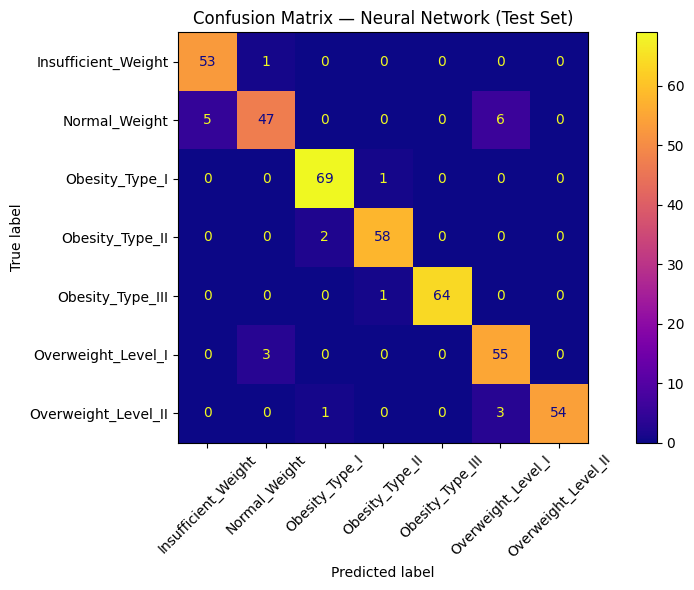

In [40]:
# TODO: Load your best configuration's weights; model.eval().

best_model = FeedForwardNet(input_dim = input_dim,hidden_sizes=(64, 32), n_classes=7)
best_model.load_state_dict(torch.load("ffn_best.pt"))
best_model = best_model.to(DEVICE)
best_model.eval()

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.metrics import accuracy_score, f1_score, classification_report
with torch.no_grad():
  test_logits= best_model(X_test_tensor.to(DEVICE))
  test_preds = test_logits.argmax(dim=1).cpu().numpy()

test_accuracy = accuracy_score(y_test_tensor.numpy(), test_preds)
test_f1 = f1_score(y_test_tensor.numpy(), test_preds, average="macro")

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1: {test_f1:.4f}")
print(classification_report(y_test_tensor.numpy(), test_preds, target_names= main_encoder.classes_))

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,6))
ConfusionMatrixDisplay.from_predictions(
    y_test_tensor.numpy(), test_preds,
    display_labels=main_encoder.classes_,
    xticks_rotation=45,
    ax=ax,
    cmap='plasma')
plt.title("Confusion Matrix — Neural Network (Test Set)")
plt.tight_layout()
plt.show()


In [42]:
#Checking the training time
import time
start = time.time()

model = FeedForwardNet(input_dim = input_dim,hidden_sizes=(64,32), n_classes=7, dropout=0.0)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loader = DataLoader(train_dataset, batch_size =32, shuffle=True)

num_epochs = 100


for epoch in range(num_epochs):
  #Training:(Looping over batches)
  model.train();
  for xb, yb in train_loader:
    optimizer.zero_grad()
    logits = model(xb.to(DEVICE))
    loss = criterion(logits, yb.to(DEVICE))
    loss.backward()
    optimizer.step()

nn_train_time= time.time() - start
print(f"Neural Network training time: {nn_train_time:.4f} seconds")

Neural Network training time: 5.9428 seconds


In [44]:
# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

import pandas as pd
import time

nn_params =sum(p.numel() for p in best_model.parameters() if p.requires_grad)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression" , "Feedforward Neural Network"],
    "Test_Accuracy": [0.8936, 0.9456],
    "Test Macro-F1": [0.8895, 0.9496],
    "Training time(s)": [0.4090, 5.9428],
    "Parameters":[147, 3655]})

comparison

,Model,Test_Accuracy,Test Macro-F1,Training time(s),Parameters
0,Logistic Regression,0.8936,0.8895,0.4090,147
1,Feedforward Neural Network,0.9456,0.9496,5.9428,3655


**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:**
1. Our neural networks confuses Overweight_Level_I and Overweight_Level_II with each other. In addition its confused Normal_Weight with Insufficient_Weight and Overweight_Level_II. These are the same three classes, Overweight_Level_I, Normal and Overweight_Level_II that our Lab2 Logistic Regression classifier also struggled with the most.Nonetheless both of the models handles the extreme classes very well to perfections  yet consistently struggle at the boundaries between the middle weight categories.

2. I believe the neural network wins the showdown on performance, as it achieved a higher test accuracy(0.9456) and macro F1 (0.9436) as compared to Logistic Regression (LR) where its test accuracy was 0.8936  and its macro F1 was 0.8895. However this came at a cost, as the neural network (NN) took more time to train (5.94s) compared to the LR which took about (0.41s). Also the NN (3655)  had way more parameters than LR (147), which makes the whole model complex to build, tune and interpret.

Yes, the extra effort of deep learning was worth this dataset because we can see an accuracy improvement in using NN as compared to LR. Moving on, I believe deep learning would be more worth the extra effort on a bigger, larger and complex set of data where using a linear model like LR would underperform by a larger margin, which would make the added training cost, time and complexity of NN fully justified.

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:**
1.
i) loss.backward() computes and stores the gradients for every parameter in the network using the chain rule (backpropagation).
ii)optimizer.step() takes the already calculated gradients and updates the weights by tuning each parameter in a direction that reduced the loss using the learning rate.
iii)The process of the loss.backward() works backward as the name suggest, through the network layer by layer, by applying the chain rule at each step to correctly assign how much layer contributed to the total error.

2. If i could tune only one hyperparameter on a new problem, i would pick the learning rate. This is because i realized that across all the experiment we took, the learning rate had the most impact and effect on the training outcomes. Based on the changes we were making, it was either the lr was too slow to converge even after the assigned maximum epoch, or the lr could converge quickly and smoothly to the best validation or it was very much unstable before it settles at a much worse loss. This showed me that getting the lr wrong can prevent a model  from learning properly to its maximum capacity, which is why it would be the first hyperparameter i would prioritize tuning first on any new problem or model.

3. I believe that the biggest train vs validation gap appeared in part 2.3's training run, where train loss stayed at 0.0000 and train accuracy stayed at 1.000 from epoch 1 through epoch 100, while validation loss  increased  from about 0.74 to 0.83 over the same period. This clearly shows that the model had fully memorized the training dataset while also performing worse on unseen data as training continued. However i do not think any interventions in this lab reduced this gap. I believe experiment C tested dropout to try and address this, but from the diagram, it is seen that the no-dropout and dropout=0.3 shows very close gaps for both impact. There dropout has no sensible effect and impact here. The other interventions, i believe could not address the gap at hand.

4. MLP would normally struggle with an image because when it is flatten MLP would treat each pixel differently and independently, just like it would treat two completely different features. MLP has no built in concept of the two pixels having a relationship or forming a pattern, therefore it would assign each pixel to their own weights. This means for larger images there is likely to be a very huge and large number of parameters which isn't a feasible approach. The property a better architecture could  have is the ability to be able to preserve the trait of spatial locality, which is the relation and connection of pixels of an image instead of treating pixels independently. A better architecture should be able to look and view the neighborhoods of pixels together and recognize that they are the same pattern. Convolutional Neural Networks (CNN) are designed for models like this and can work better here.


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.